In [1]:
import toml
import os
import sys
workspace_root = os.getcwd()
sys.path.insert(0, workspace_root + "/../../..")
from analysis import Analysis

In [2]:
# ANALYSIS SPECIFIC DIRECTORIES
ana_directory = "../../1muNp0pi_Nge1_uncontained"
data_file = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root'


Processing systematics for sample: mc
--Systematic(statistical, None)--
	Fractional uncertainty: 0.41%
--Systematic(stats, Stat.)--
	Fractional uncertainty: 0.41%
--Systematic(MC_total, All Systematics (No G4))--
	Fractional uncertainty: 0.41%

Processing systematics for sample: mc_nonmatched

Processing systematics for sample: onbeam

Processing systematics for sample: offbeam

Processing systematics for sample: rock
Setting weight for mc to 3.29e-02
Setting weight for mc_nonmatched to 3.29e-02
Setting weight for onbeam to 1.00e+00
Setting weight for offbeam to 9.53e-02
Setting weight for rock to 1.38e+00


/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/leading_muon_momentum/../../../spectra1d.py:737: RuntimeWarning: invalid value encountered in divide
  f"Fractional - Min: {(uncertainty / y_pred).min():.2%}, Max: {(uncertainty / y_pred).max():.2%}")
/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/leading_muon_momentum/../../../spectra1d.py:737: RuntimeWarning: invalid value encountered in divide
  f"Fractional - Min: {(uncertainty / y_pred).min():.2%}, Max: {(uncertainty / y_pred).max():.2%}")


Fractional - Min: nan%, Max: nan%
Fractional - Min: nan%, Max: nan%


/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/leading_muon_momentum/../../../spectra1d.py:737: RuntimeWarning: invalid value encountered in divide
  f"Fractional - Min: {(uncertainty / y_pred).min():.2%}, Max: {(uncertainty / y_pred).max():.2%}")


Fractional - Min: nan%, Max: nan%


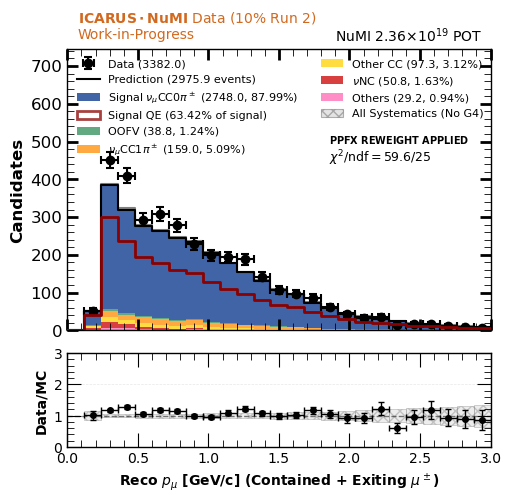

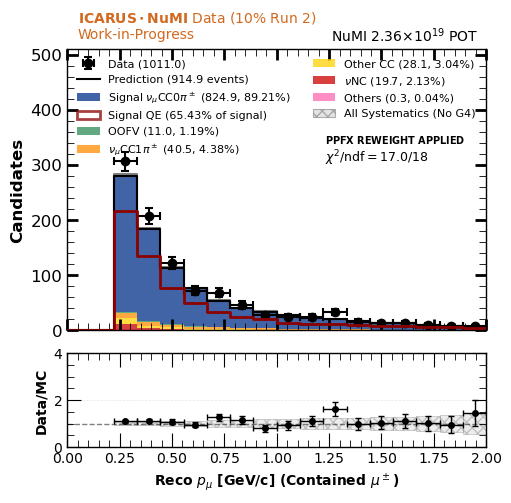

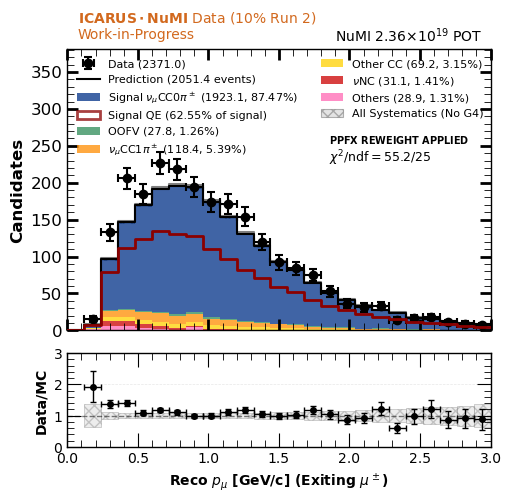

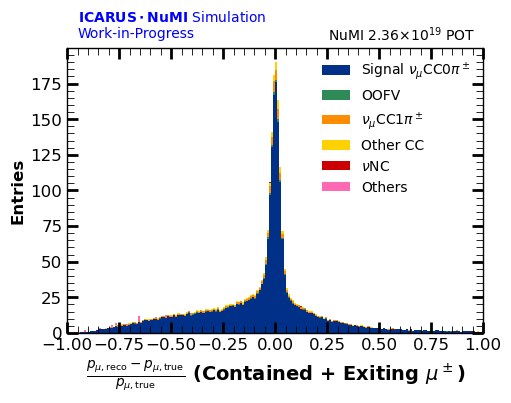

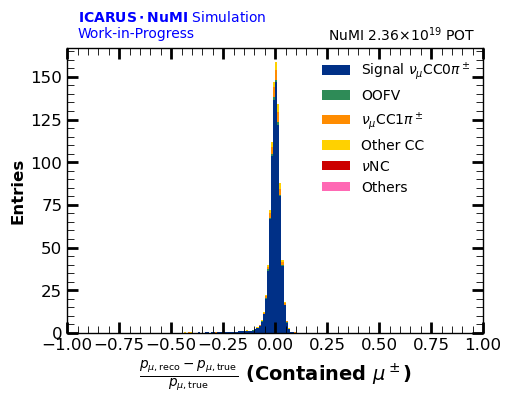

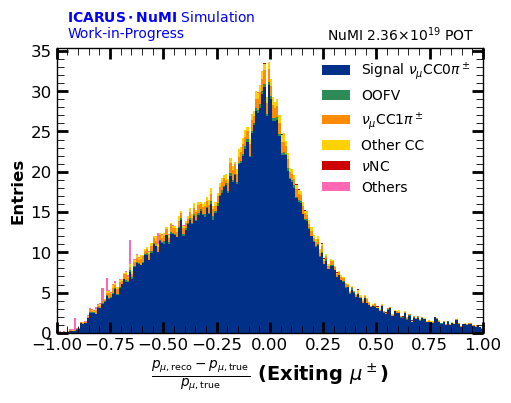

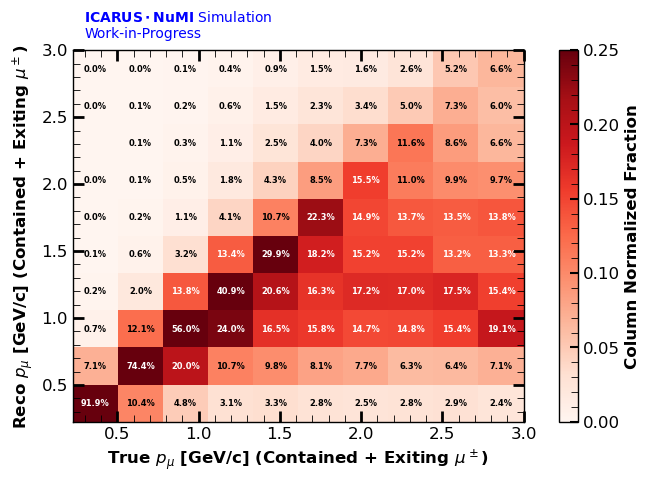

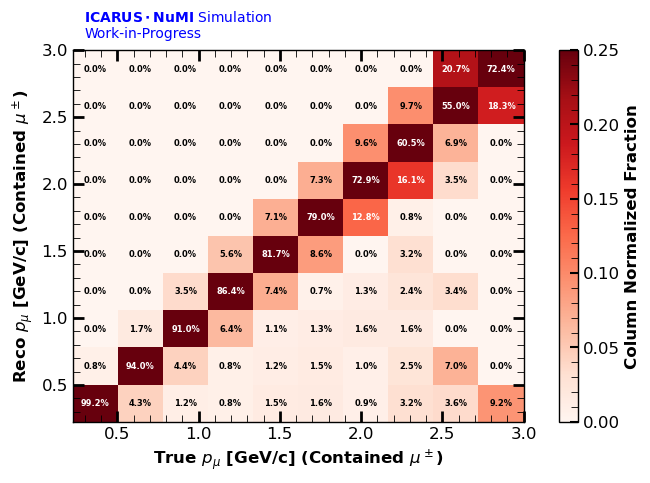

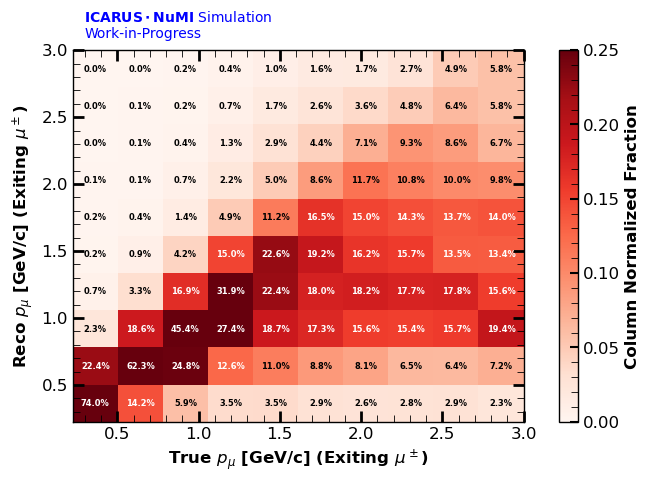

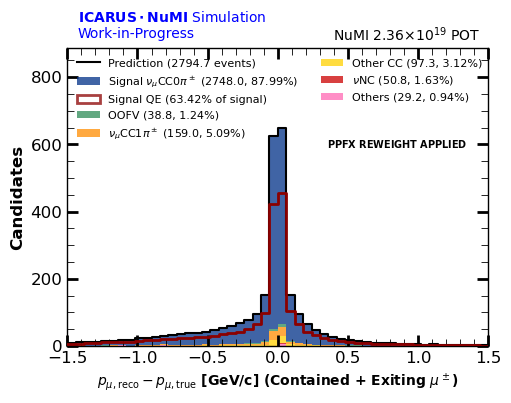

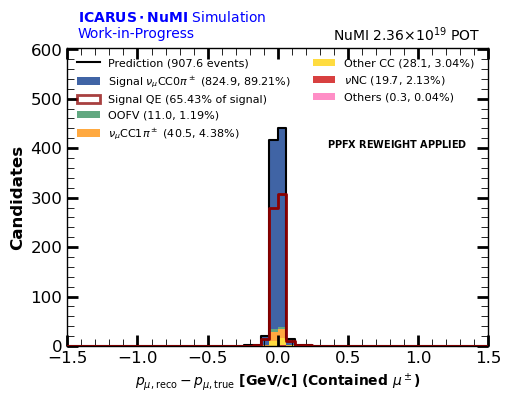

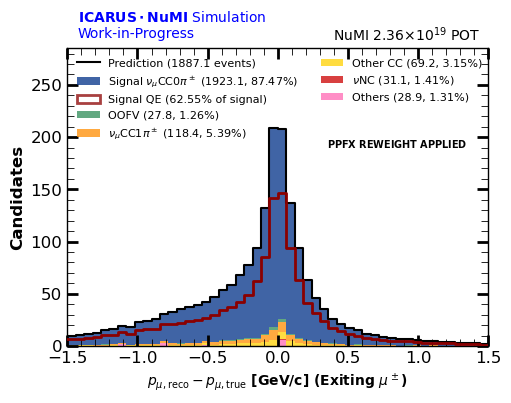

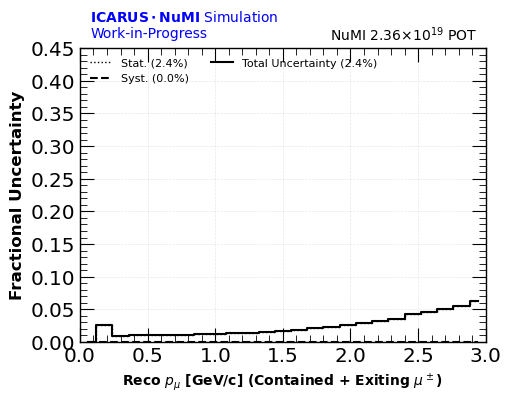

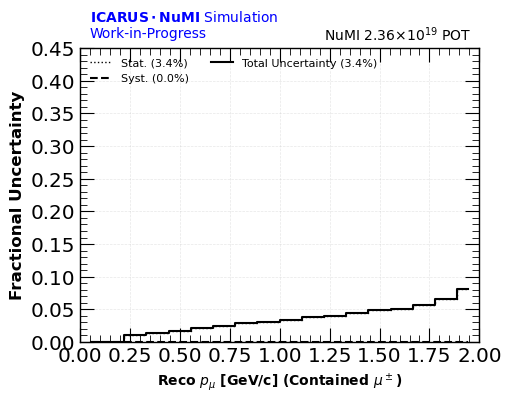

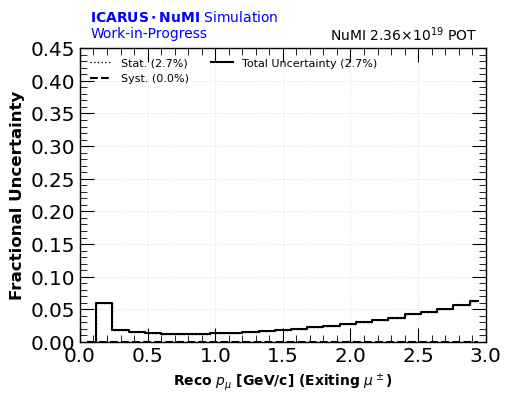

In [3]:
analysis = Analysis(ana_directory + '/leading_muon_momentum/leading_muon_momentum.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# File and tree
fpath = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_gundam_withPCA.root'

with uproot.open(fpath) as f:
    tree = f['events/full/selected']
    reco_pmu       = tree['reco_leading_muon_momentum'].array(library='np')
    true_pmu       = tree['true_leading_muon_momentum'].array(library='np')
    true_category  = tree['true_category'].array(library='np')
    muon_contained = tree['reco_leading_muon_containment'].array(library='np')

# Signal categories
signal_mask = np.isin(true_category, [0, 1, 3, 4])

# Valid kinematics mask
valid_mask = (
    np.isfinite(true_pmu) &
    np.isfinite(reco_pmu) &
    (reco_pmu < 100) &
    (true_pmu < 100)
)

# Compute absolute residual
abs_residual = reco_pmu - true_pmu

# Combined, contained, exiting masks
combined_mask  = signal_mask & valid_mask
contained_mask = signal_mask & valid_mask & (muon_contained == 1)
exiting_mask   = signal_mask & valid_mask & (muon_contained == 0)

# Binning
x_bins = np.linspace(0, 3, 16)
y_bins = np.linspace(-1.5, 1.5, 51)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(left=0.07, right=0.98, top=0.88, bottom=0.12, wspace=0.35)

titles = [
    r'Contained + Exiting $\mu^\pm$',
    r'Contained $\mu^\pm$',
    r'Exiting $\mu^\pm$'
]
masks = [combined_mask, contained_mask, exiting_mask]

for ax, mask, title in zip(axes, masks, titles):
    h, xedges, yedges = np.histogram2d(
        true_pmu[mask],
        abs_residual[mask],
        bins=[x_bins, y_bins]
    )

    im = ax.imshow(
        h.T,
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        aspect='auto',
        origin='lower',
        norm=mcolors.LogNorm(vmin=1, vmax=h.max()),
        cmap='magma'
    )

    ax.axhline(y=0, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.set_xlabel(r'True Leading Muon Momentum [GeV/c]', fontsize=12, fontweight='bold')
    ax.set_ylabel(r'$p_{\mu,\mathrm{reco}} - p_{\mu,\mathrm{true}}$ [GeV/c]',
                  fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=11, size=6, width=1.5)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Signal Events', fontsize=11, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)

plt.savefig('pdf/leading_muon_momentum_resolution_vs_true_momentum.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
analysis = Analysis(ana_directory + '/leading_muon_momentum/leading_muon_momentum_xSecUncertainty.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Leading muon momentum cross-section uncertainties expanded
analysis = Analysis(ana_directory + '/leading_muon_momentum/leading_muon_momentum_xSecUncertainty_Exp.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Leading muon momentum flux uncertainties
analysis = Analysis(ana_directory + '/leading_muon_momentum/leading_muon_momentum_FluxUncertainty.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Leading muon momentum flux uncertainties expanded
analysis = Analysis(ana_directory + '/leading_muon_momentum/leading_muon_momentum_FluxUncertainty_Exp.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Leading muon momentum detector uncertainties
analysis = Analysis(ana_directory + '/leading_muon_momentum/leading_muon_momentum_DetectorUncertainty.toml', data_file)
analysis.run(close_figs=False)